# Driving garment production efficiency through predictive analytics and smart insights.

## Executive Summary

### Context

The garment industry is a labor-intensive sector where productivity directly impacts operational costs and delivery timelines. The objective of this analysis is to predict and analyze the productivity performance of manufacturing teams. The study identifies key operational drivers and provides a tool for data-driven decision-making.

### Approach

We developed a productivity classification model based on daily task data. The analysis integrates:

- Productivity predictive modeling.
- Global Feature Importance.
- Feature relevance analysis per prediction and class.
- Input parameter tuning for productivity prediction simulations.  

### Key Insights

1. **Targeted productivity is the primary global driver of the model.**  
   Despite the shortcomings of targeted productivity for predicting productivity, it is a good input for our model.

2. **Incentives show significant predictive weight, followed by team size and SMV.**  
   This information is very important because incentives and the number of workers are levers for decision-making.

3. **Simulation of the predicted production.**  
   Using the model, it is possible to improve the predicted production using incentives, number of workers in the team, overtime; under the control of the decision-maker.

4. **Improvement of productivity prediction**
   The proposed productivity prediction has a lift of 1.47x, which means it is 47% more accurate than the baseline.

   
### Recommendation

Retain 'targeted productivity' as a core model input rather than a standalone metric.

Utilize productivity simulations as a strategic decision-making tool to optimize production lines.

## Introduction

The garment industry is a highly labor-intensive industry with lots of manual processes. So, it is highly desirable among the decision makers in the garment industry to track, analyse, and predict the productivity performance of the working teams in their factories.  
The production of a garment company is a sequential process which includes a series of operations such as designing, sample confirmation, sourcing and merchandising, lay planning, market planning, spreading and cutting, sewing, washing, finishing and packaging. The whole production target and the performance of this industry highly rely on the performance of the employees.
To keep the production performance and achieve objectives, it is systematically monitored and analyzed. Most companies are still doing this process manually.
The prediction of productivity in working teams is highly desirable among decision-makers. Furthermore, understanding the causes of low performance would enable management to take steps to optimize production and costs.

**About the dataset:**  
This dataset tracks daily production performance across different factory lines. Each line is a mix of machines and workers set up specifically for a certain clothing style. We use this data to compare performance, calculate labor costs, and plan factory capacity.

**The Main Drivers:**
- SMV (Standard Minute Value): The "target time" allowed to finish a specific task. It changes depending on the garment's complexity, fabric, and design.
- WIP (Work in Progress): The number of unfinished items currently sitting in the production pipeline (cutting, sewing, or finishing). It's a great way to spot bottlenecks.
- Overtime: Any work done beyond the standard 8-hour shift. While it helps hit deadlines, too much of it can actually hurt productivity due to worker fatigue.
- Incentives: Extra pay given to workers for hitting or exceeding their targets. In this study, we focus only on "structured" financial incentives, as they are the primary tool for boosting output.


**The Goals:**
- Predict Actual Productivity: We build models to categorize how teams will actually perform.
- Find Hidden Patterns: We extract insights from the data to answer tough business questions.
- Provide a tool for decision makers to improve the predicted productivity.

### Library and data load

In [1]:
import pandas as pd
import numpy as np
from scipy import stats



from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier


%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.metrics import precision_score, recall_score, classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold,StratifiedKFold, cross_validate, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [2]:
# load dataset
df = pd.read_csv('../datasets/garments_worker_productivity.csv')

In [3]:
# set plotting parameters
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size' : 10}
axes = { 'titlesize' : 15,
         'labelsize' : 13}
figure = {'figsize':(10,4),
          'autolayout':True,
         'titlesize' : 25,
         'labelsize' : 13}

sns.set_palette("plasma") # colorblind-friendly
plt.rc('font', **font)
plt.rc('axes', **axes)
plt.rc('figure', **figure)

## EDA

### Data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

Meaning of features:

date: Date in MM-DD-YYYY.  
day: Day of the week, represented as strings.  
quarter: A portion of the month. A month was divided into four/five quarters of seven days.  
department:	Associated department with the instance: sewing or finishing    
team_no: Associated team number with the instance.  
no_of_workers: Number of workers in each team.  
no_of_style_change:	Number of changes in the style of a particular product. Integer 0, 1 or 2.    
targeted_productivity: Targeted productivity set by the Authority for each team for each day.  
smv: Standard Minute Value, it is the allocated time for a task.  
wip: Work in progress. Includes the number of unfinished items for products.  
over_time: Represents the amount of overtime by each team in minutes (as the sum of all their members). Daily eight hours of working is counted as the normal working hour and beyond that is called overtime.  
incentive: Represents the amount of financial incentive (in BDT) that enables or motivates a particular course of action. Incentives help the employees directly through the form of higher pay for achieving the milestone or targeted performance, so it fluctuates with the change in performance level.  
idle_time: The amount of time during which the production was interrupted due to several reasons.  
idle_men: The number of workers who were idle due to production interruption.  
actual_productivity: The actual % of productivity that was delivered by the workers. It ranges from 0-1.  

### Data overview and cleaning

In [5]:
df.drop_duplicates(inplace=True)
df.head(20)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
5,1/1/2015,Quarter1,sweing,Thursday,7,0.80,25.90,984.0,6720,38,0.0,0,0,56.0,0.800125
6,1/1/2015,Quarter1,finishing,Thursday,2,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.755167
7,1/1/2015,Quarter1,sweing,Thursday,3,0.75,28.08,795.0,6900,45,0.0,0,0,57.5,0.753683
8,1/1/2015,Quarter1,sweing,Thursday,2,0.75,19.87,733.0,6000,34,0.0,0,0,55.0,0.753098
9,1/1/2015,Quarter1,sweing,Thursday,1,0.75,28.08,681.0,6900,45,0.0,0,0,57.5,0.750428


In [6]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
print(df['date'].value_counts())
print(df['date'].nunique())

date
2015-03-11    24
2015-01-31    24
2015-01-11    23
2015-03-10    23
2015-01-12    23
2015-01-24    23
2015-01-08    22
2015-01-10    22
2015-01-07    22
2015-01-13    22
2015-01-05    22
2015-03-09    22
2015-03-08    22
2015-03-03    22
2015-01-22    22
2015-02-25    21
2015-02-26    21
2015-02-28    21
2015-01-03    21
2015-01-04    21
2015-01-28    21
2015-01-27    21
2015-03-04    21
2015-01-25    21
2015-01-17    21
2015-01-14    21
2015-01-06    21
2015-02-18    21
2015-01-29    20
2015-02-17    20
2015-03-02    20
2015-03-01    20
2015-02-22    20
2015-02-19    20
2015-03-05    19
2015-03-07    19
2015-02-24    19
2015-02-23    19
2015-01-01    19
2015-02-03    19
2015-02-15    19
2015-01-15    19
2015-01-18    19
2015-01-19    19
2015-01-21    19
2015-01-26    19
2015-02-01    19
2015-02-02    19
2015-02-04    19
2015-02-07    19
2015-02-08    19
2015-02-10    19
2015-02-11    19
2015-02-12    19
2015-02-05    18
2015-02-09    18
2015-02-16    18
2015-02-14    17
2015-01-2

Trim whitespace and replace the typo: "sweing" with "sewing"

In [9]:
df['department'] = df['department'].str.strip() #correct the labels
df['department'] = df['department'].replace('sweing', 'sewing')

Let's observe that the 'finishing' was not a daily task, in fact: in January just one team in one day worked in finishing

In [10]:
df['department'] = df['department'].str.strip() #correct the labels
df['department'].value_counts()

department
sewing       691
finishing    506
Name: count, dtype: int64

In [11]:
finishing_monthly = df[df['department'] == 'finishing'] \
    .groupby(pd.Grouper(key='date', freq='ME')) \
    .size() \
    .reset_index(name='finishing_count') #group the finishing by date and count

finishing_monthly

,date,finishing_count
0,2015-01-31,235
1,2015-02-28,174
2,2015-03-31,97


In [12]:
sewing_monthly = df[df['department'] == 'sewing'] \
    .groupby(pd.Grouper(key='date', freq='ME')) \
    .size() \
    .reset_index(name='sewing_count') #group the sewing by date and count

sewing_monthly

,date,sewing_count
0,2015-01-31,307
1,2015-02-28,269
2,2015-03-31,115


We relpace the entries of quarter by their number.

In [13]:
df['quarter'] = df['quarter'].str.replace('Quarter', '')

### Data limitations

There are some rows with a non-integer number of workers.

In [14]:
(df['no_of_workers']!= np.round(df['no_of_workers'])).sum()  #detect and count non-integers

np.int64(140)

This is about 12% of data.

In [15]:
np.equal(df['no_of_workers']*2, np.round(df['no_of_workers']*2)).all() # Check if all non-integer are x.5

np.True_

We verify that all non-integer 'no_of_workers' are x.5; Since no documentation clarifies their meaning, the variable is treated as continuous and preserved without modification. 

There are some strange values for 'actual_productivity' greater than 1.

In [16]:
df[df['actual_productivity']>1]

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
337,2015-01-20,3,finishing,Tuesday,5,0.70,4.15,NaN,1440,0,0.0,0,0,8.0,1.033570
437,2015-01-26,4,finishing,Monday,3,0.75,3.94,NaN,1800,0,0.0,0,0,10.0,1.059621
456,2015-01-27,4,sewing,Tuesday,2,0.75,22.52,1635.0,6840,119,0.0,0,0,57.0,1.000230
457,2015-01-27,4,sewing,Tuesday,3,0.75,22.52,1299.0,6840,119,0.0,0,0,57.0,1.000230
477,2015-01-28,4,sewing,Wednesday,2,0.80,22.52,1559.0,6840,90,0.0,0,0,57.0,1.000230
478,2015-01-28,4,sewing,Wednesday,3,0.80,22.52,1350.0,6840,113,0.0,0,0,57.0,1.000230
498,2015-01-29,5,sewing,Thursday,2,0.80,22.52,1416.0,6840,113,0.0,0,0,57.0,1.000230
518,2015-01-31,5,sewing,Saturday,3,0.80,22.52,1136.0,6960,113,0.0,0,0,58.0,1.000457
519,2015-01-31,5,sewing,Saturday,2,0.80,22.52,1397.0,6840,113,0.0,0,0,57.0,1.000230
542,2015-02-01,1,finishing,Sunday,8,0.65,4.15,NaN,960,0,0.0,0,0,8.0,1.011562


In [17]:
df[df['actual_productivity']>1].shape

(37, 15)

We observe that there are about 3% and all below of 1.13. As no documentation is provided, they are preserved to avoid introducing undocumented transformations.

#### Missing values

From describe we can see that the only missing values are in the feature wip, and these missings are only for department 'finishing'.

In [18]:
df[df['wip'].isna()].sort_values(by='department')

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
1,2015-01-01,1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
833,2015-02-18,3,finishing,Wednesday,4,0.75,5.13,NaN,960,0,0.0,0,0,8.0,0.734646
825,2015-02-18,3,finishing,Wednesday,2,0.80,5.13,NaN,1440,0,0.0,0,0,12.0,0.919125
824,2015-02-18,3,finishing,Wednesday,6,0.80,2.90,NaN,1440,0,0.0,0,0,12.0,0.936861
823,2015-02-18,3,finishing,Wednesday,12,0.80,5.13,NaN,1200,0,0.0,0,0,10.0,0.991800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,2015-01-22,4,finishing,Thursday,2,0.70,3.94,NaN,15000,0,0.0,0,0,25.0,0.649662
383,2015-01-22,4,finishing,Thursday,1,0.70,3.94,NaN,15000,0,0.0,0,0,25.0,0.649662
382,2015-01-22,4,finishing,Thursday,4,0.75,4.30,NaN,9000,0,0.0,0,0,15.0,0.670216
401,2015-01-24,4,finishing,Saturday,12,0.70,4.08,NaN,1620,0,0.0,0,0,9.0,0.858586


We can see that all the NaN in wip are related with department 'finishing'.

There are no observations with wip = 0. A wip value of 0 is not strange in industry, so the absence of 'wip' is odd. Therefore, NaN values likely correspond to unrecorded zero wip. This assumption is also made by the producers of the dataset.

In [19]:
df['wip'] = df['wip'].fillna(0)

### Plots

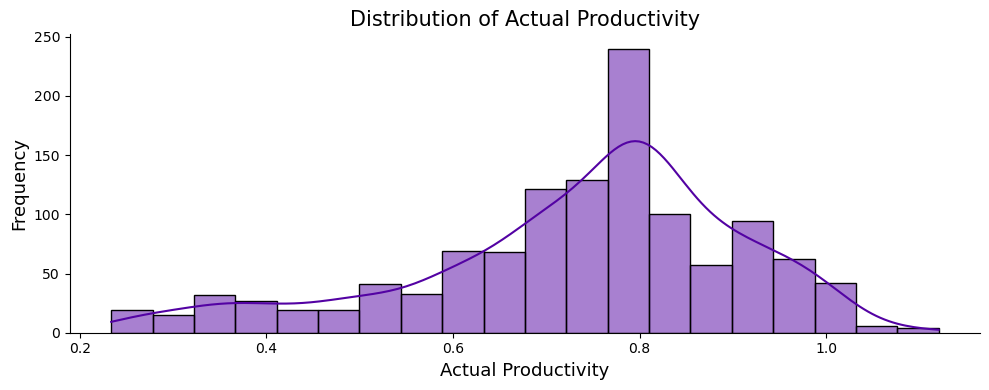

In [20]:

sns.histplot(df['actual_productivity'], 
             bins=20, 
             kde=True)

sns.despine(top=True, right=True) # quit the axes


plt.title("Distribution of Actual Productivity")
plt.xlabel("Actual Productivity")
plt.ylabel("Frequency")

plt.show()

In the productivity histogram, we can see a distribution center near 0.8. This value falls under our second productivity category, below the most desirable value.

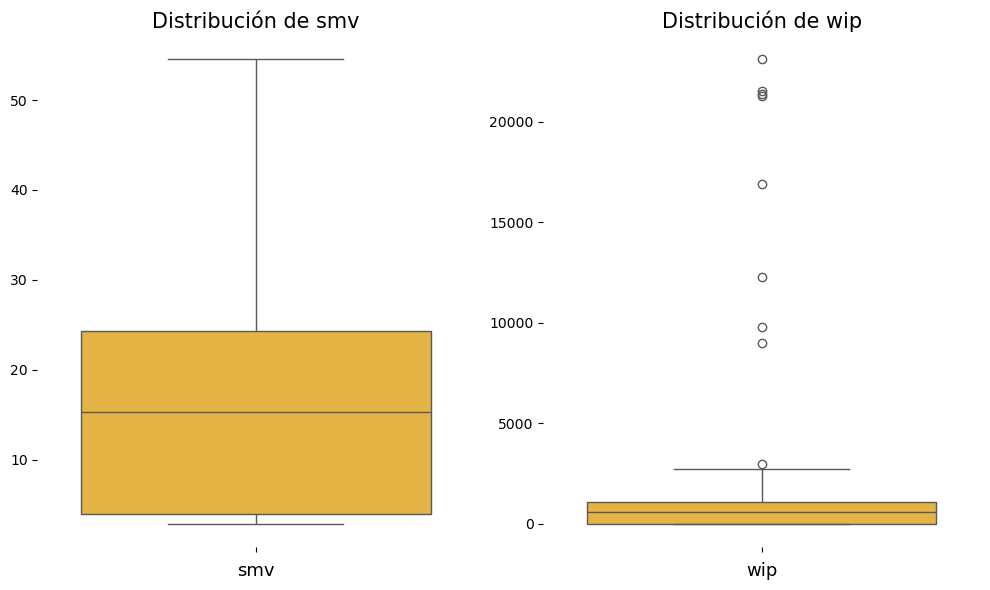

In [21]:
cols_to_plot = ['smv', 'wip'] # select columns

fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(10, 6))

axes = axes.flatten() # easier iteration

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=df, y=col, ax=axes[i], color=sns.color_palette()[5])
    axes[i].set_xlabel(col)
    sns.despine(top=True, right=True,left=True, bottom=True) # quit the box
    axes[i].set_title(f'Distribución de {col}')
    
    axes[i].set_ylabel('')


plt.show()

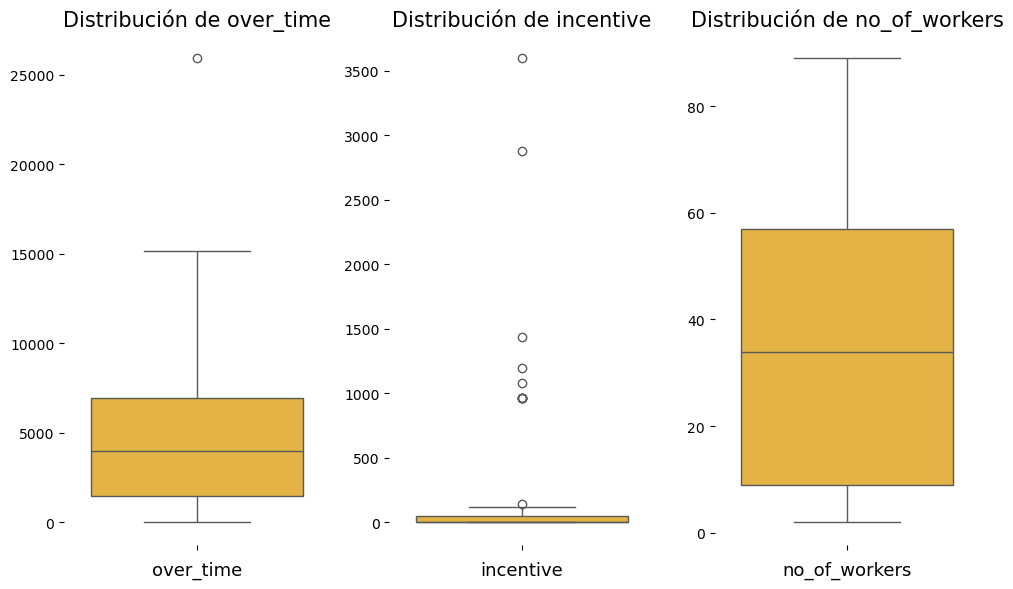

In [22]:

cols_to_plot = ['over_time',  'incentive',  'no_of_workers']


fig, axes = plt.subplots(nrows=1, ncols=3,figsize=(10, 6))

axes = axes.flatten() # easier uiteration

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=df, y=col, ax=axes[i], color=sns.color_palette()[5])
    axes[i].set_xlabel(col)
    sns.despine(top=True, right=True,left=True, bottom=True) # quit the box
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('')


plt.show()

This boxplot shows:
- Targeted productivity and actual productivity have some outlier but will be keeped due their are posible values for these features.
- SMV, no_of workers haven't outliers.
- Incentive and wip have several high outliers. We impute them with the mean.
- Over_time has one extreme outlier. We impute them with the mean. 

In [23]:
cols_quit_outliers = ['incentive', 'over_time', 'wip']

for col in cols_quit_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1    
    # define limits
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR    
    # median for impute
    median = df[col].median()
    df.loc[(df[col] < limite_inf) | (df[col] > limite_sup), col] = median

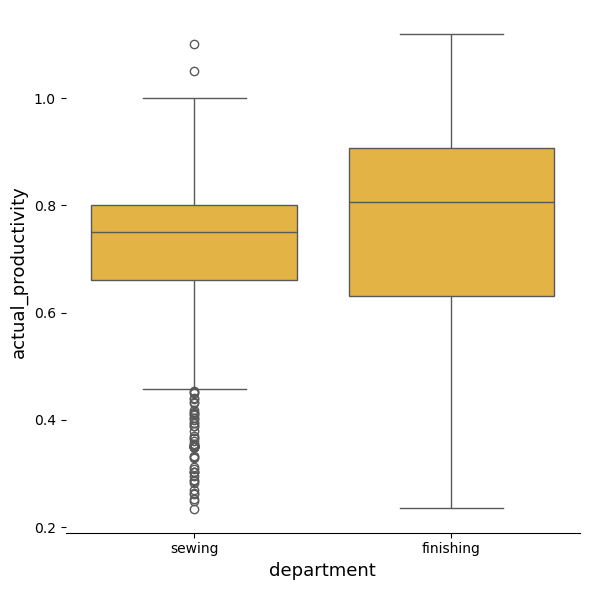

In [24]:
plt.subplots(figsize=(6, 6))
sns.boxplot(data=df, x='department', y='actual_productivity',color=sns.color_palette()[5])
sns.despine(top=True, right=True,left=True) # quit the box
plt.show()

There is little difference between the actual productivity of sewing and finishing. It is worth mentioning the more homogeneous distribution in finishing, which is evident in the short distance between quartiles compared to the outliers present in sewing.

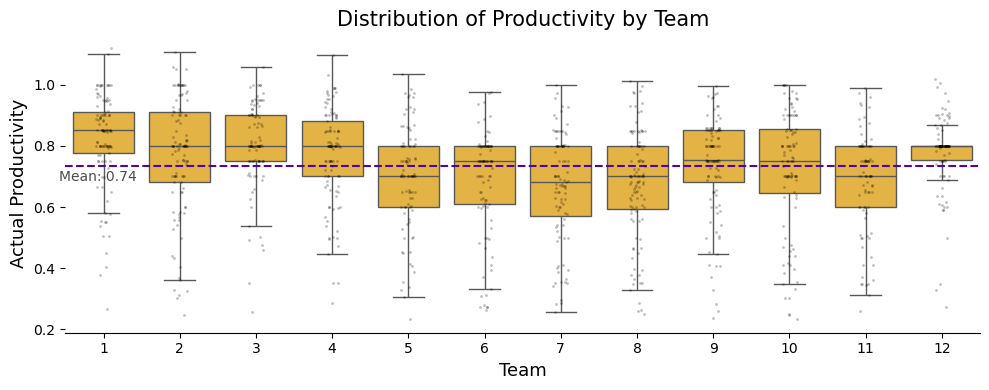

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df,
    x='team',
    y='actual_productivity',
    showfliers=False, # quit the outliers
    color=sns.color_palette()[5]
)

sns.stripplot(
    data=df,
    x='team',
    y='actual_productivity',
    color='black',
    alpha=0.25,
    size=2
)

# Line for global media actual productivity
global_mean = df['actual_productivity'].mean()
plt.axhline(global_mean, linestyle='--')
plt.text(x=-0.58, y=global_mean - 0.05, s=f'Mean: {global_mean:.2f}', 
         color='black',  alpha=0.7)

sns.despine(top=True, right=True,left=True) # quit the box
plt.title('Distribution of Productivity by Team')
plt.xlabel('Team')
plt.ylabel('Actual Productivity')

plt.show()

In these boxplots, we can see that several teams have their mean productivity above the overall average, but all teams show a large IQR and several outliers.

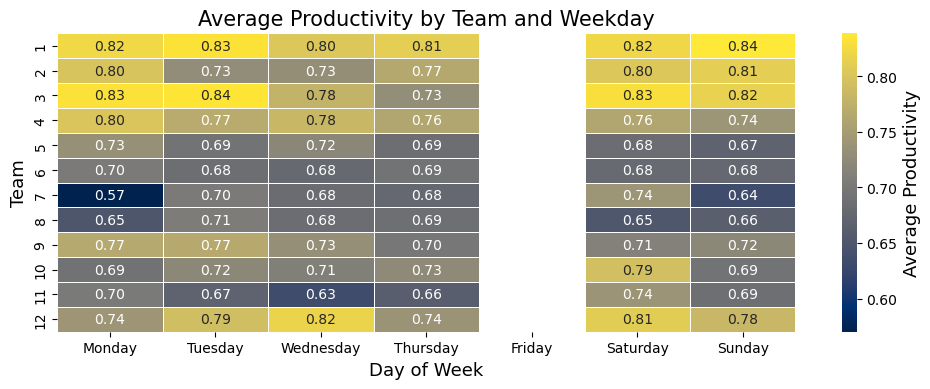

In [26]:
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# convert to categorical with proper oreder
df['day'] = pd.Categorical(df['day'],
                           categories=order_days,
                           ordered=True)

# make a table grouping by team and days, take the mean, and use days as a column
pivot = (
    df.groupby(['team','day'], observed=True)['actual_productivity']
      .mean()
      .unstack()
      .reindex(columns=order_days)
)




sns.heatmap(
    pivot,
    cmap='cividis',
    annot=True,        # show values
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Average Productivity'}
)

plt.title('Average Productivity by Team and Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Team')
plt.show()

This heatmap is another way to view the information already shown in the boxplots.

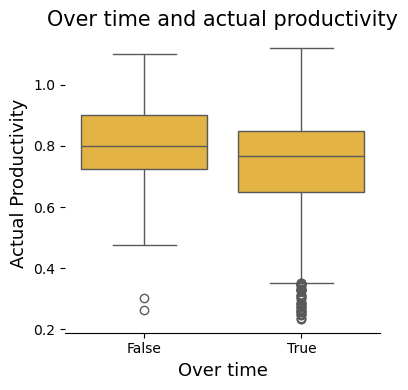

In [27]:
df['has_ot'] = df['over_time'] > 0 #make a boolean column for the plot

plt.subplots(figsize=(4, 4))
sns.boxplot(data=df,
            x='has_ot',
            y='actual_productivity',
            color=sns.color_palette()[5]);

sns.despine(top=True, right=True,left=True) # quit the box
plt.xlabel('Over time')
plt.ylabel('Actual Productivity')
plt.title('Over time and actual productivity')
plt.show()

The boxplots show that overtime seems to do not lead to an increase in productivity.

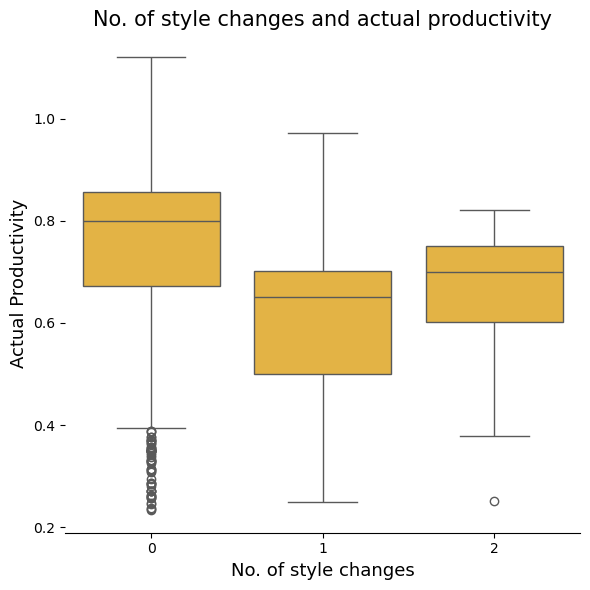

In [28]:
plt.subplots(figsize=(6, 6))
sns.boxplot(data=df, 
            x='no_of_style_change', 
            y='actual_productivity',
            color=sns.color_palette()[5])
sns.despine(top=True, right=True,left=True) # quit the box
plt.title('No. of style changes and actual productivity')
plt.xlabel('No. of style changes')
plt.ylabel('Actual Productivity')
plt.show()

By the boxplots of actual productivity grouped by number of style changes, we can see that the style changes have no clear relation with productivity

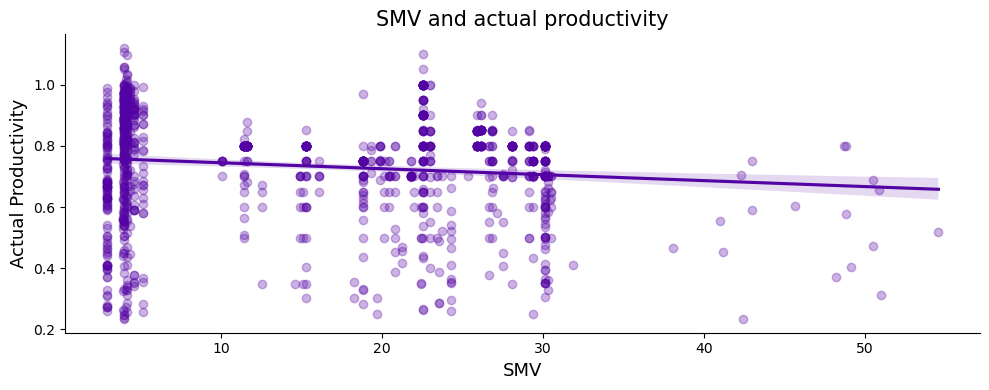

In [29]:
sns.regplot(data=df, 
            x='smv', 
            y='actual_productivity',
            scatter_kws={'alpha':0.3})
sns.despine(top=True, right=True) # quit the box
plt.title('SMV and actual productivity')
plt.xlabel('SMV')
plt.ylabel('Actual Productivity')
plt.show()


From the plot, we can see that there are typical SMV values instead of a continuous distribution.
The high heterogeneity suggests that SMV alone may not fully explain productivity, although it seems to have a negative correlation.

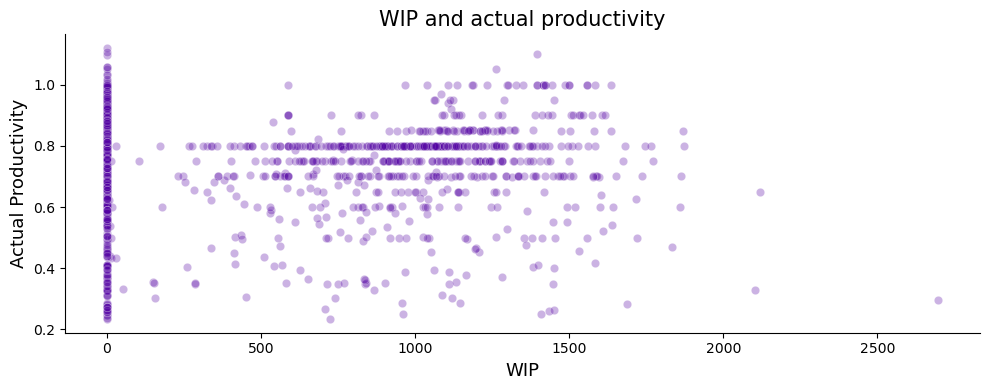

In [30]:
sns.scatterplot(data=df, x='wip', y='actual_productivity', alpha=0.3)
sns.despine(top=True, right=True) # quit the box
plt.title('WIP and actual productivity')
plt.xlabel('WIP')
plt.ylabel('Actual Productivity')
plt.show()

The relationship appears weak and the high dispersion suggests that WIP alone is not sufficient to explain productivity differences.

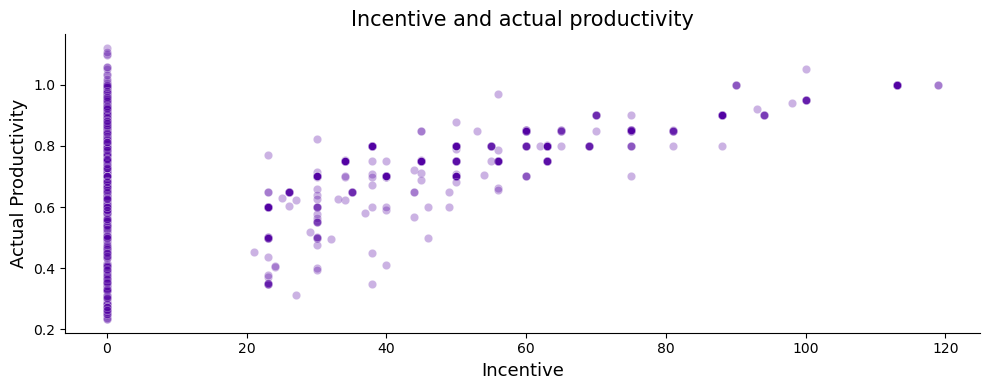

In [31]:
sns.scatterplot(data=df, x='incentive', y='actual_productivity', alpha=0.3)
sns.despine(top=True, right=True) # quit the box
plt.title('Incentive and actual productivity')
plt.xlabel('Incentive')
plt.ylabel('Actual Productivity')
plt.show()

We can see a fairly linear relationship between actual productivity and incentive (for not 0 incentive)

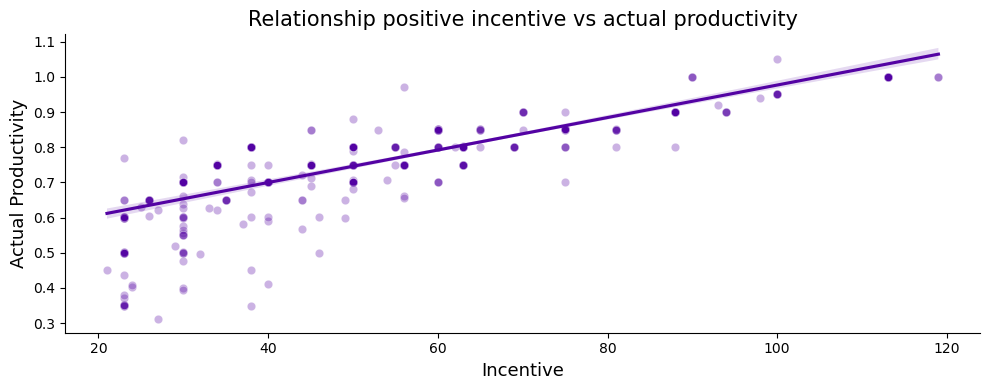

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# plot the points wit positive incentive
sns.scatterplot(data=df[df['incentive'] > 0], x='incentive', y='actual_productivity', alpha=0.3)

# we add the linear fit
sns.regplot(data=df[df['incentive'] > 0], 
            x='incentive', 
            y='actual_productivity', 
            scatter=False)

plt.title("Relationship positive incentive vs actual productivity")
plt.xlabel('Incentive')
plt.ylabel('Actual Productivity')
sns.despine(top=True, right=True) # quit the box
plt.show()

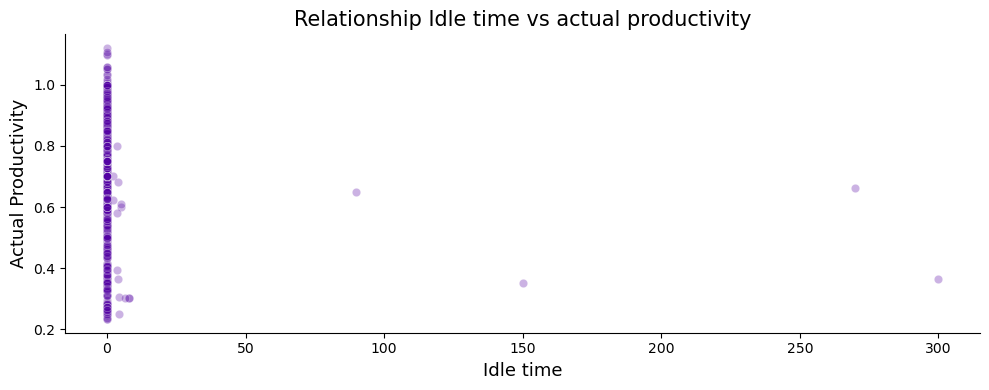

In [33]:
sns.scatterplot(data=df, x='idle_time', y='actual_productivity', alpha=0.3)
plt.title("Relationship Idle time vs actual productivity")
plt.xlabel('Idle time')
plt.ylabel('Actual Productivity')
sns.despine(top=True, right=True) # quit the box
plt.show()

In the same way than incentive, the big number of zero values makes hard to find a correlation. But, even discading the zeros, they are clustered near zero, then we apply a logarithmic scale for improve visualization.

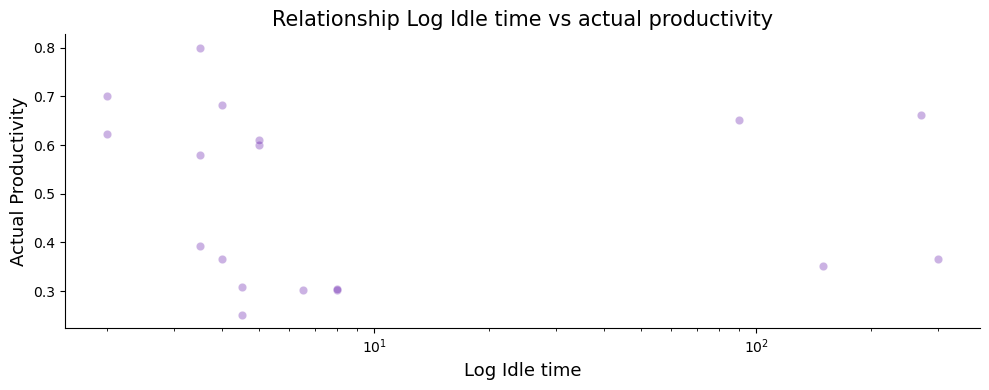

In [34]:
sns.scatterplot(data=df[df['idle_time'] > 0], x='idle_time', y='actual_productivity', alpha=0.3)
plt.title("Relationship Log Idle time vs actual productivity")
plt.xlabel('Log Idle time')
plt.ylabel('Actual Productivity')
sns.despine(top=True, right=True) # quit the box
plt.xscale('log')
plt.show()

Whether using a logarithmic scale or not, the relationship remains unclear.

We analyze the relationship between actual productivity and targeted productivity

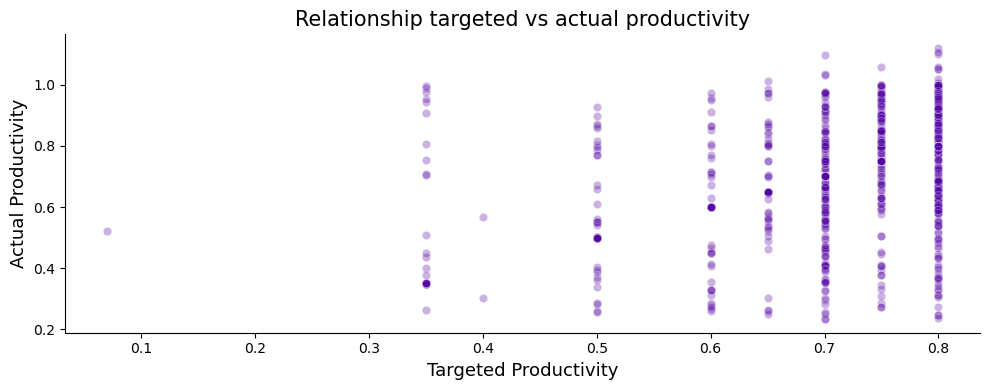

In [35]:
sns.scatterplot(data=df, x='targeted_productivity', y='actual_productivity', alpha=0.3)
plt.title("Relationship targeted vs actual productivity")
plt.xlabel('Targeted Productivity')
plt.ylabel('Actual Productivity')
sns.despine(top=True, right=True) # quit the box
plt.show()

We can observe that the numbers have a granularity of 0.05 and an upper bound at 0.8.

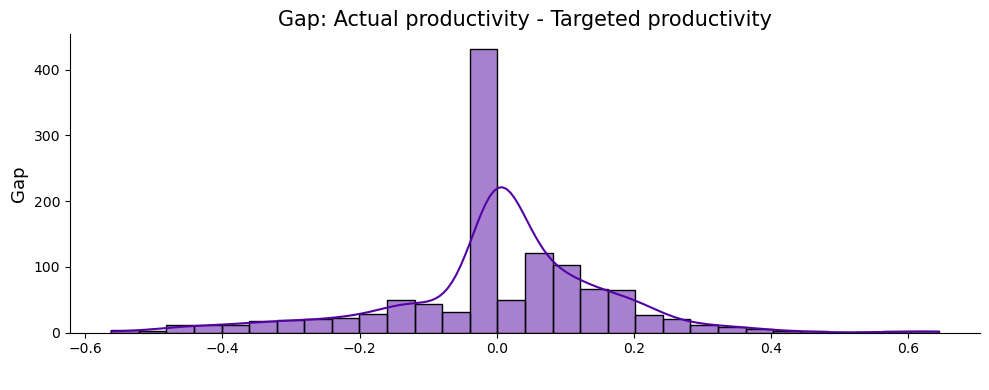

In [36]:
df['gap'] = df['actual_productivity'] - df['targeted_productivity']

sns.histplot(df['gap'],kde=True, bins=30);
plt.title("Gap: Actual productivity - Targeted productivity")
plt.xlabel(' ')
plt.ylabel('Gap')
sns.despine(top=True, right=True) # quit the box
plt.show()

The distribution of the productivity gap is approximately centered around zero, suggesting that, on average, actual productivity aligns with the targeted levels. Although slight asymmetry may be present, there is no strong evidence of systematic overestimation or underestimation in the targets.

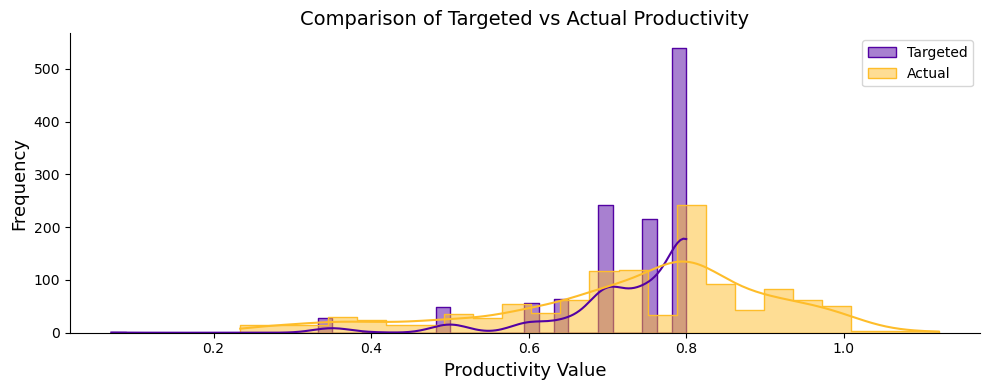

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hist Targeted Productivity
sns.histplot(df['targeted_productivity'], 
             label='Targeted', 
             kde=True,
             element="step")

# Hist Actual Productivity
sns.histplot(df['actual_productivity'], 
             color=sns.color_palette()[5], 
             label='Actual', 
             kde=True, 
             element="step")


plt.title('Comparison of Targeted vs Actual Productivity', fontsize=14)
plt.xlabel('Productivity Value')
plt.ylabel('Frequency')
sns.despine(top=True, right=True) # quit the box
plt.legend() # Importante para saber cuál es cuál

sns.despine() # Quita los bordes innecesarios
plt.show()

In these histograms, we confirm that they are aligned in their mode but not in median or average. Targeted productivity has a strong ceiling and is more concentrated.

Finally, we apply a Wilcoxon Signed-Rank Test to establish the no alignment.

In [38]:
# Ho: There is no significant difference between actual and targeted productivity
# Ha: There is a significant difference
stat, p_value = stats.wilcoxon(df['actual_productivity'], df['targeted_productivity'])

print(f"Statistic: {stat:.4f}, p-value: {p_value:.4e}")

if p_value < 0.05:
    print("Significant differences exist: the goal-setting process is NOT neutral.")
else:
    print("No evidence of bias: the targets are well-aligned with reality.")

Statistic: 263027.5000, p-value: 9.9696e-15
Significant differences exist: the goal-setting process is NOT neutral.


The Wilcoxon Signed-Rank Test yielded a p-value very near 0 (9.97e-15), indicating a statistically significant difference between actual and targeted productivity. Given that the median gap is negative, we can conclude that the management is currently underestimating the production capacity of the teams

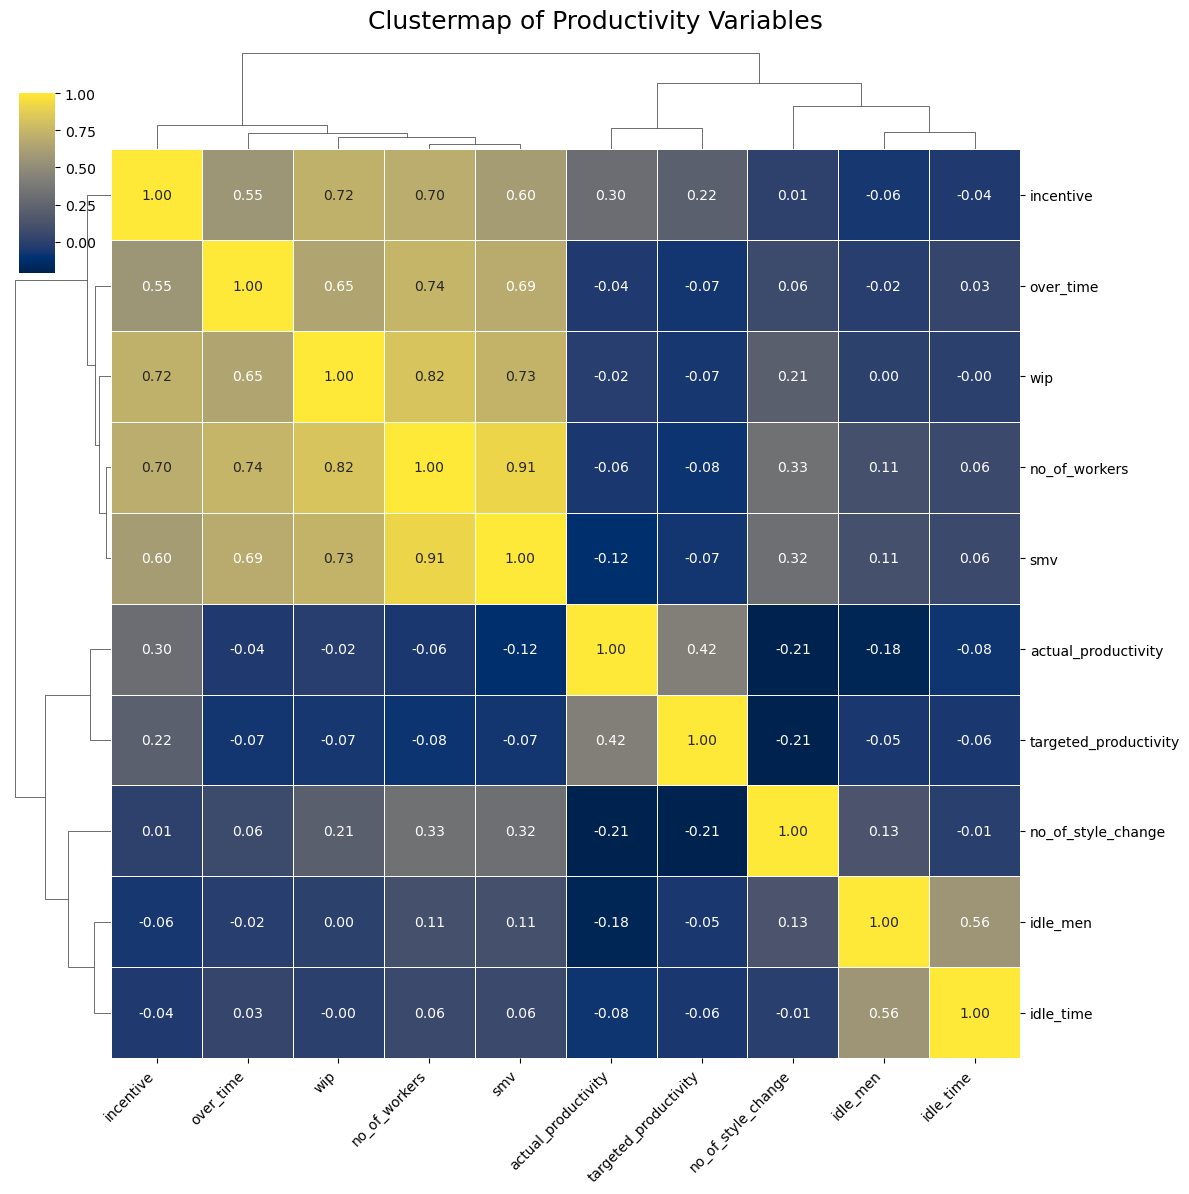

In [39]:
columns = [
    'idle_men', 'idle_time', 'no_of_workers', 
    'smv', 'wip', 'over_time', 'incentive', 
    'actual_productivity', 'targeted_productivity', 'no_of_style_change'
]

# 


correlation_matrix = df[columns].corr()
g = sns.clustermap(
    correlation_matrix,
    method='ward',      # Clustering method (minimizes variance)
    cmap='cividis',
    annot=True,
    fmt=".2f",
    figsize=(12, 12),   
    linewidths=0.5,
    dendrogram_ratio=(.1, .1), # size of "branches"
    cbar_pos=(0.02, 0.8, 0.03, 0.15) # legend position
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.fig.suptitle('Clustermap of Productivity Variables', fontsize=18, y=1.02)
plt.show()

Using this clustermap, we have the information usual in a correlation matrix but ordered, providing insights into the underlying structure of the data through the dendrograms.  
The data reveal a natural and very strong correlation between idle workers and idle time. We also observe significant positive correlations between the number of workers and key variables such as SMV, WIP, and overtime, as well as between WIP and incentives.

Furthermore, SMV and overtime show a notable positive correlation. While there is a positive relationship between actual and targeted productivity, it is not as strong as the operational correlations mentioned above. Finally, the most relevant negative correlation, although moderate, exists between targeted productivity and the number of style changes.

## Categorical productivity

The variable actual_productivity was discretized into four ordinal categories (0-3) to align the statistical analysis with operational performance tiers. This transformation facilitates the identification of patterns across teams, reduces the impact of minor fluctuations (noise) in measurement, and provides a clearer framework for categorical association tests such as Chi-Square or Cramer's V

In [40]:
df['prod_cat'] = pd.cut(
    df['actual_productivity'],
    bins=[0, 0.7, 0.8, 0.9, float('inf')],
    labels=[0, 1, 2, 3],
    right=False
)


In [41]:
df['prod_cat'].value_counts()

prod_cat
0    365
2    363
1    266
3    203
Name: count, dtype: int64

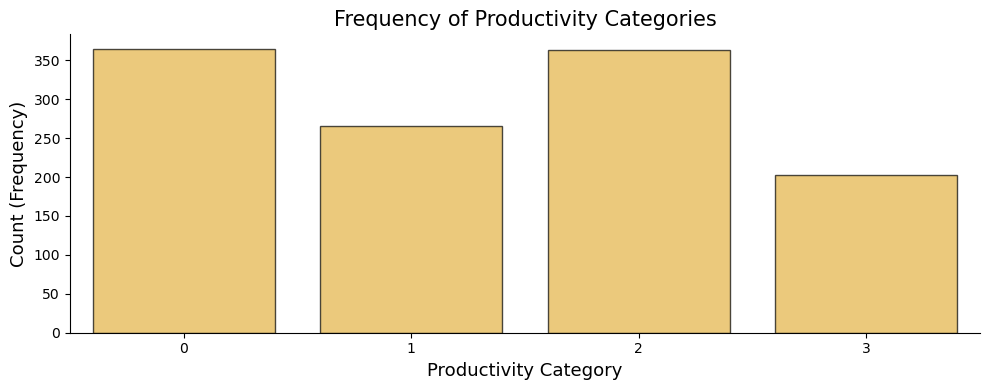

In [42]:
sns.countplot(
    data=df, 
    x='prod_cat', 
    color=sns.color_palette()[5],
    edgecolor='black', 
    alpha=0.7
)

# 3. Estética
plt.title('Frequency of Productivity Categories')
plt.xlabel('Productivity Category')
plt.ylabel('Count (Frequency)')

sns.despine() 
plt.show()

We analyze the association between 'cat_prod' and the rest of categorical variables, including 'team' and 'no_of_style_change' in categorical variables. We can do this because:  
- Despite than 'team' is numerical, has low cardinality and their orden have not meaning.
- 'no_style_change', although numeric in representation, functions as an ordinal scale. Treating the variable as categorical allows the model to capture non-linear relationships, as we saw in the boxplots vs 'actual_productivity'

In [43]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

def chicramer(var1,var2,df):
    # create contingency table
    contingency_table = pd.crosstab(df[var1], df[var2])
    
    # Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Cramer's V test
    n = contingency_table.sum().sum() 
    min_dim = min(contingency_table.shape) - 1 
    cramer_v = np.sqrt(chi2 / (n * min_dim))
    print(f"For variables {var1} and {var2} the results of the test are:")
    print(f"Chi2 p-value: {p:.4e}")
    print(f"Cramer's v: {cramer_v:.4f}")

variables_to_analize=['department', 'day', 'team', 'quarter','no_of_style_change']

for var in variables_to_analize:
    chicramer(var,'prod_cat',df)

For variables department and prod_cat the results of the test are:
Chi2 p-value: 4.5897e-23
Cramer's v: 0.2991
For variables day and prod_cat the results of the test are:
Chi2 p-value: 4.3980e-01
Cramer's v: 0.0650
For variables team and prod_cat the results of the test are:
Chi2 p-value: 8.1471e-25
Cramer's v: 0.2328
For variables quarter and prod_cat the results of the test are:
Chi2 p-value: 1.7601e-08
Cramer's v: 0.1299
For variables no_of_style_change and prod_cat the results of the test are:
Chi2 p-value: 7.2152e-17
Cramer's v: 0.1919


For all variables but 'day', the p-value is much smaller than 0.5. Therefore, all variables but 'day' has impact on 'prod_cat'.  From Cramer's V test, we can see that the association is weak for all variables except for 'department'.

This categorical classification of productivity allows us to have well-represented classes.

### EDA summary

Number of days: 59

Number of teams: 12

Number of registers: 1197

Data limitations:  
- Missing values: 0 (there were 506 NaN assumed as 0, according to the bibliography).
- 'no_of_workers' has some non-integer values (12% of values). Since no documentation clarifies their meaning, the variable is treated as continuous and preserved without modification
- 'actual_productivity' has a 3% of data greater than 1 and all below 1.13. As no documentation is provided, they are preserved to avoid introducing undocumented transformations.
- Incentive and wip have several high outliers. We impute them with the mean.
- Over_time has one extreme outlier. We impute them with the mean.

Production distribution by category:  
Low (under 70%): 365  
Middle-low (between 70 and 80%) 363  
Middle-high (between 80 and 90%): 266  
High (above 90%): 203  
 
Categorical features: 6 (department, day, team, quarter, date, no_of_style_change)

Numerical features: 10 (targeted_productivity, smv, wip, over_time, incentive, idle_time, idle_men,  no_of_workers, actual_productivity)

Target: prod_cat, categorical ordinal.

Note 1: the team is numerical, but its numerical value doesn't concern therefore, it is treated as categorical.
Note 2: actual_productivity must be removed for machine learning, because it will produce data leakage.

**Main observations:**
- The Wilcoxon Signed-Rank Test confirms a statistically significant bias ($p < 0.001$), revealing that targeted productivity systematically underestimates actual productivity.
- We also observe significant positive correlations between the number of workers and key variables such as SMV, WIP, and overtime, as well as between WIP and incentives.
- SMV and overtime show a notable positive correlation
- The most relevant negative correlation exists between targeted productivity and the number of style changes.
- From Chi-sqare and Cramer's V test, we can consider negligible the effect of: 'day', 'team', 'quarter'and 'no_of_style_change'.
- The data reveal a natural and very strong correlation between idle workers and idle time. 

## Machine Learning

In [44]:
# load dataset
df = pd.read_csv('../datasets/garments_worker_productivity.csv')
df['date'] = pd.to_datetime(df['date'])
df['wip']=df['wip'].fillna(0)
df['prod_cat'] = pd.cut(
    df['actual_productivity'],
    bins=[0, 0.7, 0.8, 0.9, float('inf')],
    labels=[1, 2, 3, 4],
    right=False
)
RANDOM_STATE = 43 # fix random state for all the tasks

In [45]:
# Define target
target = 'prod_cat'

# Define categorical columns
categorical_cols = [
    'department', 'day', 'team', 'quarter'
]

# Define numerical columns
numeric_cols = ['targeted_productivity',  'no_of_style_change',
                'smv', 'wip', 'over_time', 
                'incentive', 'idle_time', 'idle_men',
                'no_of_workers']

# separate features and target
X = df[categorical_cols + numeric_cols]
y = df[target]

We modify the labels because XGBost needs labels begining in 0.

'date' was excluded because the date can't be repeated, and we do not use temporal/seasonal information. 'no_of_style_change' was included among the numeric columns to keep their ordinal feature.

In [46]:
le = LabelEncoder()
y = le.fit_transform(y)

We define the models and preprocessor

In [47]:
# define models with usual parameters
models = {
    "LogReg": LogisticRegression(max_iter=1000, 
                                 random_state=RANDOM_STATE),
    "SVC": SVC(probability=True, 
               random_state=RANDOM_STATE), 
    "RandomForest": RandomForestClassifier(
        n_estimators=300, 
        random_state=RANDOM_STATE, 
        class_weight='balanced'
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softmax",
        num_class=4,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        importance_type='gain',
        class_weight='balanced'
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        bootstrap=True,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5) 
}
# preprocesor pipeline
numeric_transformer = Pipeline([('scaler', StandardScaler())])
# encode for categorical variables
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
# combination of preprocessors
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_cols),
                                               ('cat', categorical_transformer, categorical_cols)])




We split the dataset into training (70%) and testing (30%) sets. We used stratified sampling to ensure that the distribution of productivity classes remains consistent across both subsets, preventing potential bias during model evaluation.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.3, 
    random_state = RANDOM_STATE, 
    stratify = y # take care of low cardinality categories
)

To ensure that all classes are well-represented, we use stratified K-fold cross-validation.

In [49]:
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state = RANDOM_STATE) # This makes a crossvalidation stratified, considering the unbalanced chrun

In [50]:

metrics = {
    'F1': 'f1_macro',
    'BalAcc': 'balanced_accuracy',
    'MAE': 'neg_mean_absolute_error',
}

results_table = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ]) #construct the pipeline for each model
    
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=skf,
        scoring=metrics,
        n_jobs=-1
    ) 
    
    results_table.append({
        'Model': name,
        'F1 macro average': scores['test_F1'].mean(),
        'Balanced Accuracy': scores['test_BalAcc'].mean(),
        'MAE': -scores['test_MAE'].mean(),
    })

df_results = pd.DataFrame(results_table)
print(df_results)

          Model  F1 macro average  Balanced Accuracy       MAE
0        LogReg          0.518154           0.516586  0.667851
1           SVC          0.597866           0.591658  0.596195
2  RandomForest          0.710819           0.712064  0.396645
3       XGBoost          0.702878           0.704577  0.410948
4      LightGBM          0.700600           0.701626  0.413334
5    ExtraTrees          0.708730           0.710022  0.396611
6           KNN          0.568091           0.565888  0.611740


Some words about these metrics:  
F1 macro average: this is the average of applying F1 to each class; F1-Score is a combination of precision and recall, that is: grow up with good classified and penalize bad classified. For this metric, higher values are better.  
Balanced accuracy: The average proportion of correctly identified instances within each class. For this metric, higher values are better.  
MAE: is an average of the distance between the predicted and the actual class of each prediction. For this metric, lower values are better.

Therefore, the best model is Random Forest

In [51]:
# Set the pipeline with the selected model
pipe_final =Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators = 300, 
                                           random_state = RANDOM_STATE,
                                           class_weight = 'balanced')
    )
])

# Set the parameters grid for searching
param_distributions = {
    "model__n_estimators": [100, 200, 500, 800],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ['sqrt', 'log2', None],
    "model__bootstrap": [True, False],
    "model__class_weight": ['balanced', 'balanced_subsample', None]
}

search = RandomizedSearchCV(pipe_final, 
                            param_distributions = param_distributions, 
                            n_iter = 25, 
                            cv = skf, # the crosvalidation stratified
                            scoring = 'neg_mean_absolute_error',
                            random_state = RANDOM_STATE,
                            n_jobs = -1) # use max procesors

search.fit(X_train, y_train)

print(f"Best MAE after tuning: {-search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Best MAE after tuning: 0.4170
Best params: {'model__n_estimators': 800, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 20, 'model__class_weight': 'balanced', 'model__bootstrap': True}


In [52]:
from sklearn.metrics import balanced_accuracy_score
best_model = search.best_estimator_
y_pred=best_model.predict(X_train)
print(f"F1-score after tuning: {f1_score(y_train, y_pred, average='macro'):.4f}")
print(f"Balanced accuracy after tuning: {balanced_accuracy_score(y_train, y_pred):.4f}")

F1-score after tuning: 0.9333
Balanced accuracy after tuning: 0.9392


Despite the parameters were tunning for MAE, we get very good values for the other metrics.

### Model Results and Evaluation

We compute the metrics of our best model in the test set

In [53]:

best_model = search.best_estimator_
y_pred=best_model.predict(X_test)
print(f"MAE in test set: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"F1-score in test set: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Balanced accuracy in test set: {balanced_accuracy_score(y_test, y_pred):.4f}")

MAE in test set: 0.4917
F1-score in test set: 0.6935
Balanced accuracy in test set: 0.6985


The MAE in test set are a little worst than in train set, with a bigger difference for F1 and balanced accuracy

Using our best model and parameters we analize the results obtained, comparing actual productivity and predicter productivity.

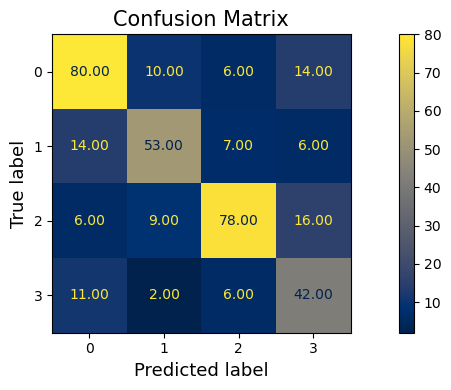

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='cividis',
    values_format='.2f', 
    ax=plt.gca(),        
    colorbar=True        
)
plt.title("Confusion Matrix")
plt.show()


Now, we consider these errors in proportion to categories

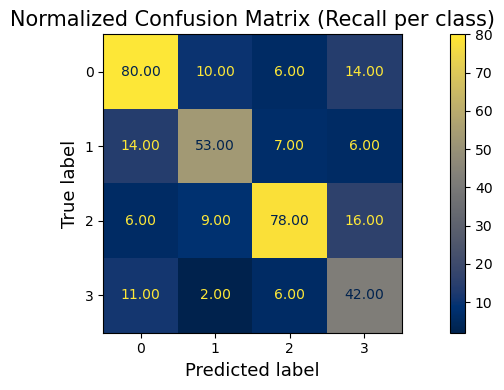

In [55]:
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='cividis',
    values_format='.2f', 
    ax=plt.gca(),        
    colorbar=True        
)

plt.title("Normalized Confusion Matrix (Recall per class)")
plt.show()

We can see that every category has more correct labeled than incorrect labels.

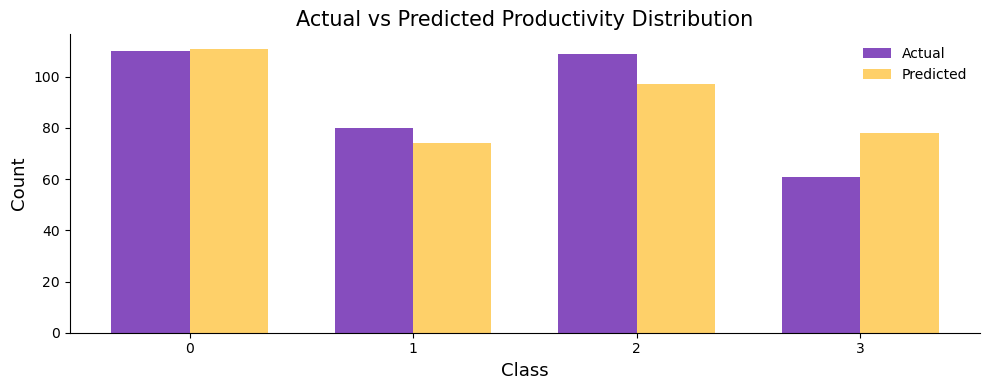

In [56]:
classes = np.unique(y_test)

real_counts = [np.sum(y_test == c) for c in classes]
pred_counts = [np.sum(y_pred == c) for c in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure()
plt.bar(x - width/2, real_counts, width, label="Actual",alpha=0.7)
plt.bar(x + width/2, pred_counts, width, label="Predicted",color=sns.color_palette()[5],alpha=0.7)

sns.despine() 
plt.xticks(x, classes)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Actual vs Predicted Productivity Distribution")
plt.legend(frameon=False)
plt.show()

We can see that the middle categories has less prediction than actual values.

Analyzing the distance between predicted and actual labels reveals a decreasing frequency, which is a positive indicator for the model's performance.

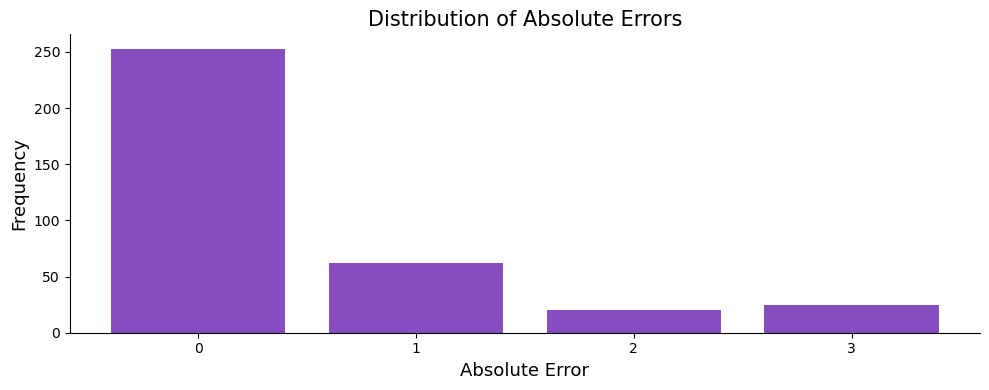

In [57]:
abs_errors = np.abs(y_test - y_pred)

# possible values (0,1,2,3)
error_values = np.arange(abs_errors.max() + 1)

# count
counts = [np.sum(abs_errors == i) for i in error_values]

plt.figure()

plt.bar(error_values, counts,alpha=0.7)
plt.xticks(error_values)  
sns.despine() 
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Errors")
plt.show()


Finally, we analize the feature importance

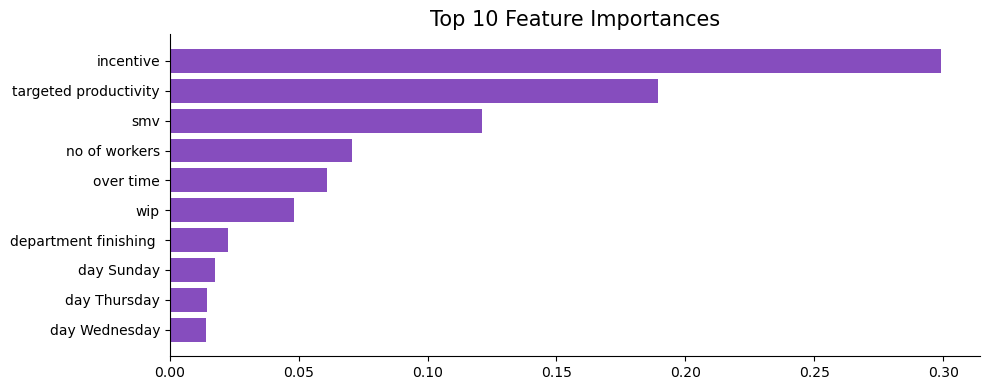

In [58]:

final_model = best_model.named_steps["model"]

importances = final_model.feature_importances_
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
display_names=[]
for feat_name in feature_names:
    base_name = feat_name.split("__")[-1]          # quit prefix num__ o cat__
    if base_name in df.columns:
         display_names.append(base_name.replace("_", " "))
    else:
        display_names.append(base_name.replace("_", " "))  # fallback al nombre transformado


feat_imp = pd.DataFrame({
    "Feature": display_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Top 10
top10 = feat_imp.head(10)

plt.figure()
plt.barh(top10["Feature"], top10["Importance"], alpha=0.7)
sns.despine() 
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

Here we can see that incentive is the main feature, followed very closely by targeted productivity.

In the next level, smv is relevant; Later, no of workers, over time and wip. The rest of the features have lower relevance.


We will use SHAP. SHAP builds on Shapley values from cooperative game theory, which provide a mathematically principled way to distribute “credit” among players in a game. In our problem, the “game” is making the prediction, and the “players” are the features. Each feature gets credit based on its marginal contribution across all possible combinations of features.

We show that in some examples

In [59]:
# extract model and preprocessor
final_model = best_model.named_steps['model']
preprocessor = best_model.named_steps["preprocess"]

# transform data
X_train_transformed = preprocessor.transform(X_train)
#X_test_transformed = preprocessor.transform(X_test)

# get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# make a dataframe of transformed
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
#X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# create explainer with train data
background = shap.sample(X_train_transformed_df, 100)  # 100 random samples for speed up
explainer = shap.Explainer(final_model, background)


def plot_waterfall(sample, preprocessor, model, explainer,sample_name=''):
    ''' This function take a sample of data, calculate Shapley values and plot a waterfall for 
    category in order to show the impact of each eature in the final prediction.
    Variables:
    sample: a dataframe with the sample of variables to predict and analize.
    model: the model used for predictions
    prepreocessor: the preprocessor used for transform the data.
    explainer: the Shapley explainer trained with data and model.
    sample_name: a string for the title'''
    
    # transform the sample
    sample_transformed = preprocessor.transform(sample)
    feature_names = preprocessor.get_feature_names_out()
    sample_transformed_df = pd.DataFrame(sample_transformed, columns=feature_names)

    # calculate the prediction
    pred_class = model.predict(sample_transformed_df.iloc[[0]].values)[0]
    
    # calculate Shapley values
    shap_val = explainer.shap_values(sample_transformed_df, approximate=True)
    
    if isinstance(shap_val, list):
        shap_list = shap_val
    else:
        #change the format 3D (n_samples, n_features, n_classes) to list of n_classes arrays of shape (n_samples, n_features)
        shap_list = [shap_val[:, :, i] for i in range(shap_val.shape[2])]

    # Change names and data for visualization
    display_data = []
    display_names = []

    for feat_name in feature_names:
        base_name = feat_name.split("__")[-1]          # quit prefix num__ o cat__
        
        if base_name in sample.columns:
            # If the name is a feature from the original dataframe
            value = sample[base_name].iloc[0]
            display_data.append(value)
            display_names.append(base_name.replace("_", " "))
        else:
            # If the name isn't a feature from the original dataframe
            parts = base_name.split('_', 1)
            display_data.append(parts[1])
            display_names.append(f"{parts[0]}")  
  
    
    # plot
    fig, axes = plt.subplots(2, 2, figsize=(25, 12))
    axes = axes.flatten()

    # base values for each class
    ev = explainer.expected_value
    
    for i, ax in enumerate(axes):
        
        plt.sca(ax)
        
        # calculate explanation for the sample
        exp = shap.Explanation(
            values=shap_list[i][0], 
            base_values=ev[i] if hasattr(ev, '__len__') else ev,
            data=np.array(display_data), 
            feature_names=display_names
        )

        # plot
        shap.plots.waterfall(exp, max_display=12, show=False)
        
        # format
        ax.set_title(f"Class {i}", fontsize=14, pad=15)
        ax.tick_params(axis='y', labelsize=8)
        for text in ax.texts:
            text.set_fontsize(7)

    # fit space between subplots
    plt.subplots_adjust(wspace=1.5, hspace=0.8)
    plt.suptitle(f"Waterfall plots for the sample {sample_name} - Prediction: class {pred_class}",
             fontsize=16, fontweight='bold', y=1.02)

    
    plt.show()

We analize the sample number 1 of our test set, for this sample the features and prediction are:

The next plot shows that, by default, each sample has a probability of being classified in each category (shown as $E[f(x)]$). The value of each feature pushes the probability up or down, according to the arrow. The color of the arrow indicates if the present value of the features is high (red) or low (blue) with respect to the dataset.

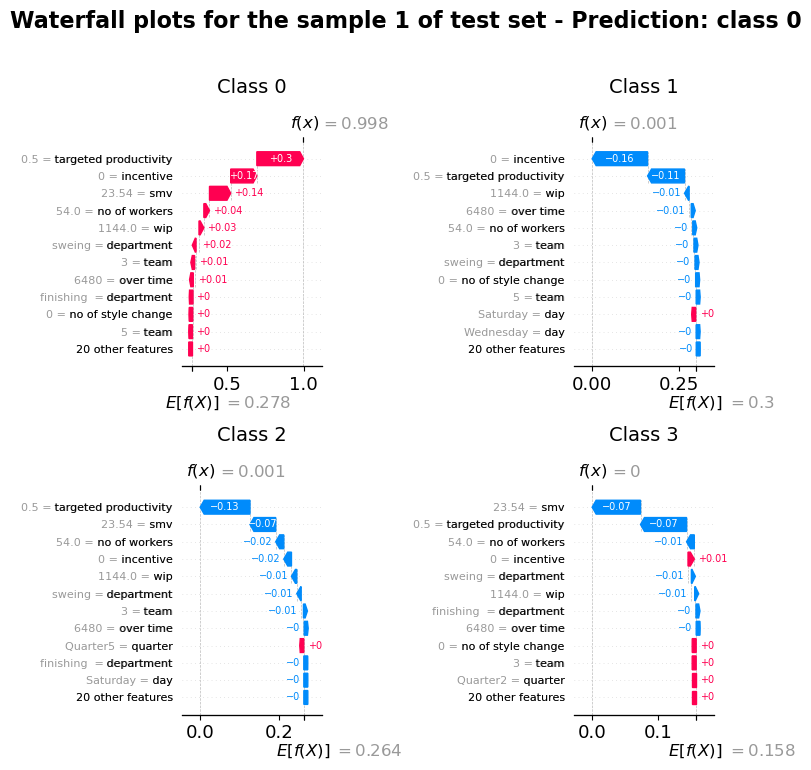

In [60]:
plot_waterfall(X_test.iloc[[0]], preprocessor, final_model, explainer, '1 of test set')

We observe that, a priori, the most probable class is 1 (because of $E(F(x))=0.303$), but the prediction is obtained by summing this a priori probability with the effect of all the features. We analyze the impact of the most relevant features:
- 'targeted_productivity': is the feature with the biggest feature importance, pushes up strongly class 0 and pulls down the rest of the classes.
- 'incentive' with value 0. push-up  class 0 and pull-down the rest of the classes.
- 'smv': has the same effect as previous features but with lower strength.
- 'no_of_workers': has relevance only for class 0, for this sample. And has a negative impact.
- 'over_time': has low relevance for this sample

After summing up all these effects, we obtain that the probability for class 0 is 0.996; for class 1 is 0.004; and 0 for class 2 and 3.

Finally, we make some comparison between our prediction of productivity, targeted productivity and actual productivity

In [61]:
# y_test: actual values, y_pred: our predicted values
reporte = classification_report(y_test, y_pred)
print(reporte)

              precision    recall  f1-score   support

           0       0.72      0.73      0.72       110
           1       0.72      0.66      0.69        80
           2       0.80      0.72      0.76       109
           3       0.54      0.69      0.60        61

    accuracy                           0.70       360
   macro avg       0.69      0.70      0.69       360
weighted avg       0.71      0.70      0.71       360



In [62]:
y_targeted = X_test['targeted_productivity'].astype('float')

y_targeted = pd.cut(
    X_test['targeted_productivity'],
    bins=[0, 0.7, 0.8, 0.9, float('inf')],
    labels=[0, 1, 2, 3],
    right=False
).astype('float')
# y_test: actual values, y_targeted: targeted productivity in classes
reporte = classification_report(y_test, y_targeted, zero_division=0)
print(reporte)

              precision    recall  f1-score   support

           0       0.65      0.30      0.41       110
           1       0.46      0.81      0.59        80
           2       0.48      0.73      0.58       109
           3       0.00      0.00      0.00        61

    accuracy                           0.49       360
   macro avg       0.40      0.46      0.39       360
weighted avg       0.44      0.49      0.43       360



We can observe that all metrics but recall for class 1 and 2 are better in our prediction. 

### Machine Learning Summary

**Models Evaluated:** Logistic Regression, Support Vector Classifier (SVC), Random Forest, XGBoost,LightGBM, ExtraTrees, and KNN .<br>
**Preprocessing:** StandardScaler for numerical variables and OneHotEncoder for categorical variables.<br>
**Data Split:** Stratified Train-Test split (70% - 30%).<br>
**Model Selection:** Conducted using **Cross-Validation with Pipelines** to prevent data leakage.<br>
**Final Model: Random Forest** was selected based on the MAE metric.<br>
**Hyperparameter Tunning:** Performed via RandomizedSearchCV.<br>  
MAE (Train): 0.4170<br>
**MAE (Test): 0.4917**

**Feature Importance & Insights:** <br>
Based on the model coefficients, we observed the following:<br>
- Targeted productivity and incentive are the main features.
- smv and no of workers are quite relevant features
- Over time and wip are in a third level of importance
- The rest of the features have lower relevance.
- The impact of each variable is different in terms of sense and relevance for each class, and with high interaction with other variables.
- Middle classes (1 and 2) have less prediction than actual values.
- The distance between predicted and actual labels reveals a decreasing frequency, that's mean: big mistakes are less frequent.

## Industrial implications

In the garment industry, by traditional methods, they calculate the expected productivity (in our dataset: targeted productivity). Our model also provides an expected productivity by class. In this section we compare the quality of both estimations using the classes determined for our machine learning model.

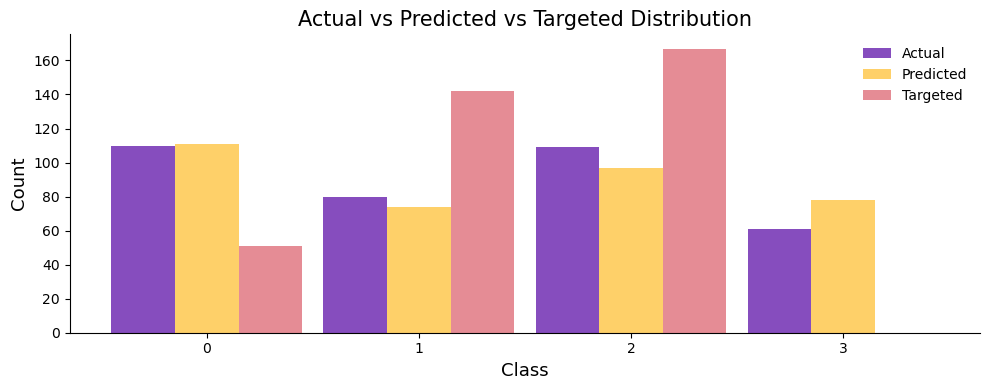

In [63]:
classes = np.unique(y_test)
y_targeted = X_test['targeted_productivity'].astype('float')

y_targeted = pd.cut(
    X_test['targeted_productivity'],
    bins=[0, 0.7, 0.8, 0.9, float('inf')],
    labels=[0, 1, 2, 3],
    right=False
).astype('float')

# count frequences
actal_counts = [np.sum(y_test == c) for c in classes]
pred_counts = [np.sum(y_pred == c) for c in classes]
targ_counts = [np.sum(y_targeted == c) for c in classes]

x = np.arange(len(classes))
width = 0.3

plt.figure()
plt.bar(x - width, actal_counts, width, label="Actual",alpha=0.7)
plt.bar(x , pred_counts, width, label="Predicted",color=sns.color_palette()[5],alpha=0.7)
plt.bar(x + width, targ_counts, width, label="Targeted",color=sns.color_palette()[3],alpha=0.7)

plt.xticks(x, classes)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Actual vs Predicted vs Targeted Distribution")
sns.despine()
plt.legend(frameon=False)
plt.show()

It is clear that our prediction is better than targeted distribution, for measuring that we count the disctance of eache prediction with the actual value. We count the frequency of each possible distance for the targeted and predicted productivity

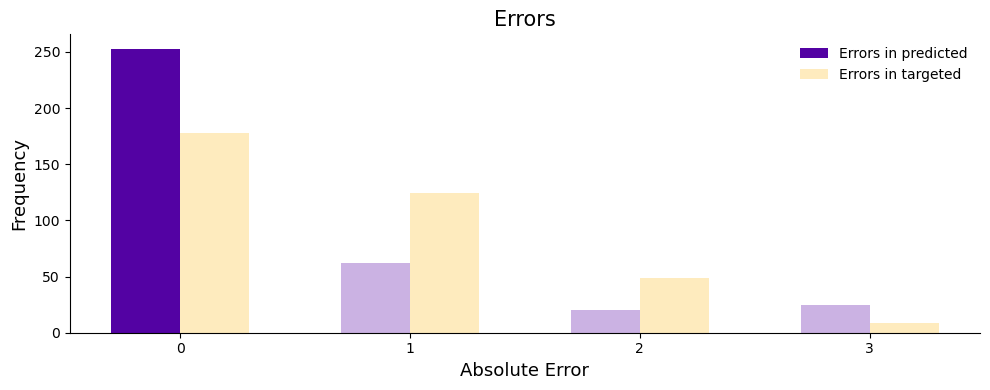

In [64]:
abs_errors_pred = np.abs(y_test - y_pred)
abs_errors_targ = np.abs(y_test - y_targeted)

# possible values (0,1,2,3)
error_values = np.arange(abs_errors_pred.max() + 1)

# Count
counts_pred = [np.sum(abs_errors_pred == i) for i in error_values]
counts_targ = [np.sum(abs_errors_targ == i) for i in error_values]

fig, ax = plt.subplots()
width = 0.3
pred_bar = ax.bar(error_values- width/2, counts_pred,width, label="Errors in predicted")
targ_bar = ax.bar(error_values+ width/2, counts_targ,width, label="Errors in targeted",color=sns.color_palette()[5])


opacity_faded = 0.3 # for fade bars
# first bar normal, the rest: faded
for i, bar in enumerate(pred_bar):
    if i != 0:  
        bar.set_alpha(opacity_faded)
    
for bar in targ_bar:
    bar.set_alpha(opacity_faded)
    
plt.xticks(error_values)  # ticks enteros
sns.despine()
plt.legend(frameon=False)
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Errors")
plt.show()


In this plot, a 0 value means a correct prediction, and the other values is the distance between the actual and predicted class. Only in distance 3, our prediction has more errors. Therefore, our prediction is a better tool than the traditional method with lift of 47.19%.

In [65]:
from sklearn.metrics import accuracy_score

acc_target = accuracy_score(y_test, y_targeted)

acc_model = accuracy_score(y_test, y_pred)

lift = (acc_model - acc_target) / acc_target * 100

print(f"Accuracy of targeted productivity: {acc_target:.2%}")
print(f"Accuracy of predicted productivity: {acc_model:.2%}")
print(f"Lift: {lift:.2f}%")

Accuracy of targeted productivity: 49.44%
Accuracy of predicted productivity: 70.28%
Lift: 42.13%


### A tool for improving production

Furthermore, using the shap waterfalls the garment authorities could set some parameters in order to achive a better productivity. Let analyze an example:



Let consider the next situation
    'quarter': 1
    'department': sewing	
    'day': Tuesday	
    'team': 3	
    'targeted_productivity': 0.8	
    'smv': 22.52	
    'wip': 1112.0	
    'over_time': 6840	
    'incentive': 0	
    'idle_time': 0.0	
    'idle_men': 0  
    'no_of_style_change': 0   
    'no_of_workers': 57.0

If we apply our predictor, we obtain

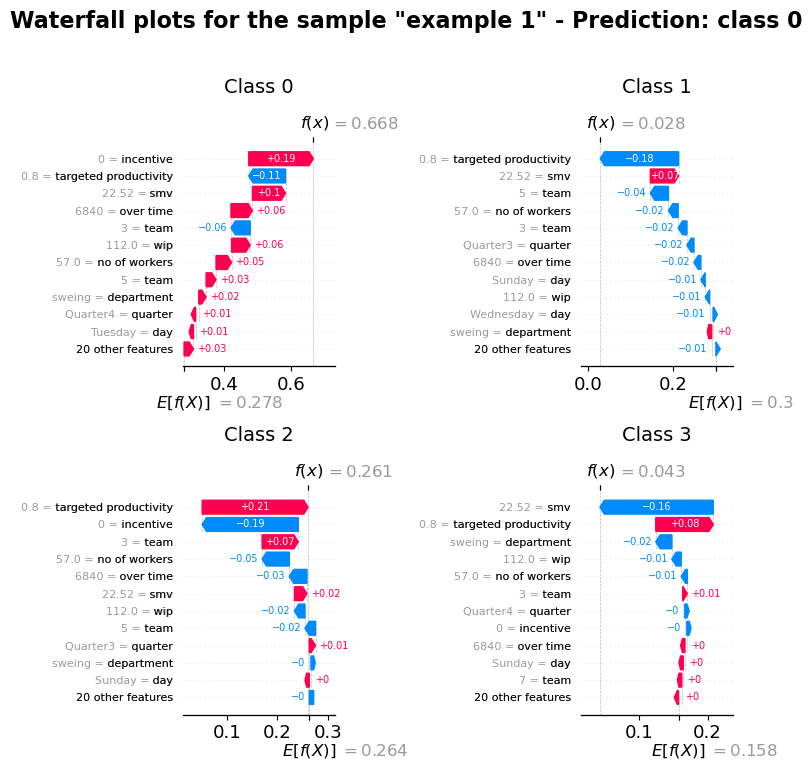

In [66]:
data = {
    'quarter' : ['Quarter1'],
    'department': ['sweing'],
    'day': ['Tuesday'],
    'team': [3],
    'targeted_productivity': [0.8],
    'smv': [22.52],
    'wip': [112.0],
    'over_time': [6840],
    'incentive': [0],
    'idle_time': [0.0],
    'idle_men': [0],
    'no_of_style_change': [0],
    'no_of_workers': [57.0]
}

#finishing	Monday	6	0.75	2.9	0.0	960	0	0.0	0	0	8.0
#sewing	Tuesday	3	0.8	22.52	1112.0	6840	100	0.0	0	0	57.0

categorical_cols = [
    'department'
]

# Define numerical columns
numeric_cols = ['targeted_productivity',
                'smv', 'wip', 'over_time', 
                'incentive', 'idle_time', 'idle_men',
                'no_of_workers']


# Creamos el DataFrame
df_sample = pd.DataFrame(data)


plot_waterfall(df_sample,preprocessor, final_model, explainer,'"example 1"')

We can see a productivity of class 2, that incentive is pulling down the chances of class 3. Therefore, we could try to improve the productivity incrementing incentive. Let consider an incentive of 100 and keeping the rest of variables:

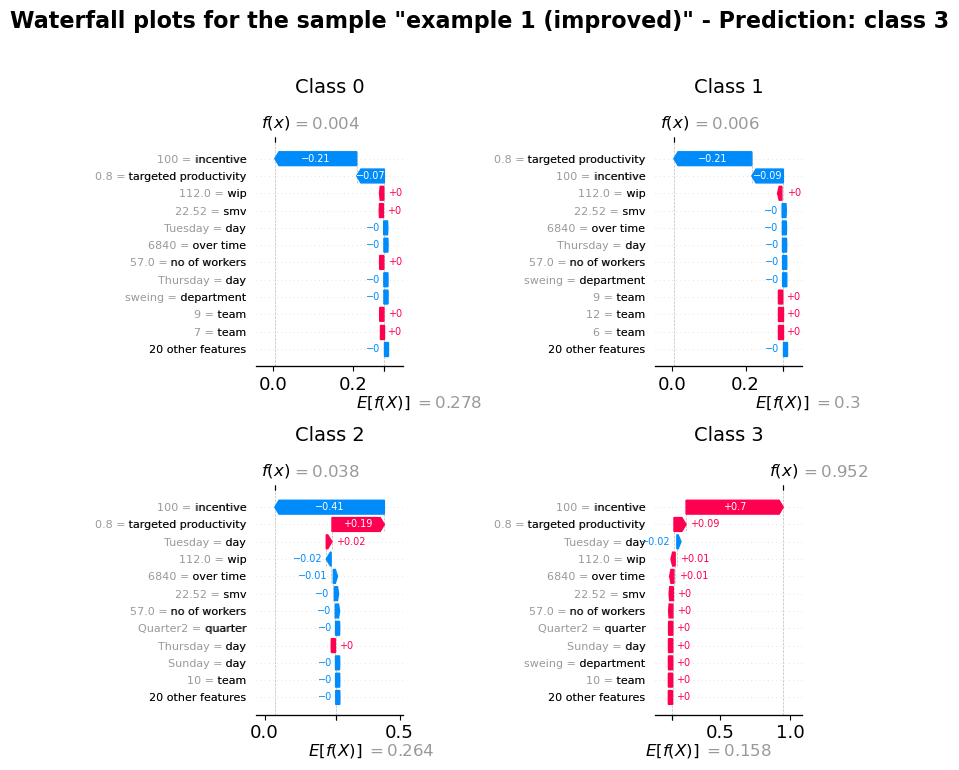

In [67]:
data = {
    'quarter' : ['Quarter1'],
    'department': ['sweing'],
    'day': ['Tuesday'],
    'team': [3],
    'targeted_productivity': [0.8],
    'smv': [22.52],
    'wip': [112.0],
    'over_time': [6840],
    'incentive': [100],
    'idle_time': [0.0],
    'idle_men': [0],
    'no_of_style_change': [0],
    'no_of_workers': [57.0]
}

# Creamos el DataFrame
df_sample = pd.DataFrame(data)

plot_waterfall(df_sample,preprocessor, final_model, explainer,'"example 1 (improved)"')

Is worth to metion than the predicted productivity obtained for our model does not ensure reaching such productivity. Nevertheless, we can say that this class has a 76.5% of probability.

### Industrial implications summary

- The model obtained allows garment authorities to make better predictions, 47%  which enables them to make better decisions.
- The predictions obtained with the waterfall analysis allow garment authorities to try different values for some lever features in order to obtain higher productivity.